# Chi-square test
A $\chi^2$ test is a statistical method used to analyze categorical data to determine if observed frequencies differ significantly from expected frequencies.

## Is survival related to passenger class?

Hypotheses:
- Null hypothesis ($H_0$): Survival and passenger class are independent
- Alternative hypothesis ($H_1$): Survival and passenger class are associated

In [3]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")

# Keep relevant columns
df_clean = df[["Survived", "Pclass"]].dropna()

df_clean

,Survived,Pclass
0,0,3
1,1,1
2,1,3
3,1,1
4,0,3
...,...,...
886,0,2
887,1,1
888,0,3
889,1,1


### Create Contingency Table

In [6]:
contingency_table = pd.crosstab(df_clean["Pclass"], df_clean["Survived"])
print(contingency_table)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


### Run Chi-Square Test

Degree of freedom represents the number of independent categories or observations that can vary in a test after accounting for constraints (like total sample size)

In [7]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 102.88898875696056
p-value: 4.549251711298793e-23
Degrees of freedom: 2


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Survival depends on passenger class")
else:
    print("Fail to reject H0: No evidence of association")

Reject H0: Survival depends on passenger class


### Visual inspection

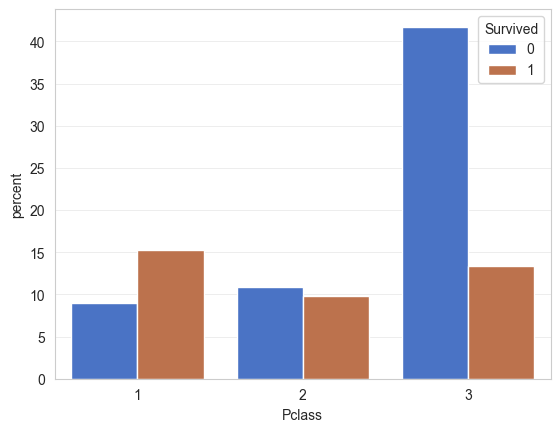

In [24]:
sns.set_style('whitegrid')

sns.countplot(data=df_clean, x='Pclass', hue='Survived', stat='percent')

plt.show()

## Is survival related to gender?

Hypotheses:
- $H_0$: survival is not related to gender
- $H_1$: survival is related to gender

In [25]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")

# Keep relevant columns
df_clean = df[["Survived", "Sex"]].dropna()

df_clean

,Survived,Sex
0,0,male
1,1,female
2,1,female
3,1,female
4,0,male
...,...,...
886,0,male
887,1,female
888,0,female
889,1,male


### Create contingency table

In [28]:
contingency_table = pd.crosstab(df["Sex"], df["Survived"])

print(contingency_table)


Survived    0    1
Sex               
female     81  233
male      468  109


In [29]:

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("p-value:", p_value)

p-value: 1.197357062775565e-58


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Survival is associated with gender")
else:
    print("Fail to reject H0: No evidence of association")

Reject H0: Survival is associated with gender
